Synthetic ice inversion using adjoints
=======================================================
In the previous tutorials we have seen how to run Glacial Isostatic Adjustment (GIA) models forward in time. Two of the key
ingredients are an ice loading history and a viscosity structure of the mantle. However, like many problems in Earth Sciences,
these inputs are not known. We need to infer these unknown inputs based on any geological and geophysical observations that
we can get our hands on! In the GIA problem this is often in the form of paleo relative sea level markers and present day geodetic observations.

In this tutorial, we will demonstrate how to perform an inversion to recover the ice thickness distribution of an
idealised GIA simulation using G-ADOPT. We make the important assumption that we know the viscosity
structure of the mantle. In reality, this is not the case, but it will simplify things for this first example!

The tutorial involves a *twin experiment*, where we assess the performance of the inversion scheme by inverting the
ice thickness distribution to match a synthetic reference simulation, known as the "*Reference Twin*". To create this reference twin, we
run a forward GIA simulation and record all relevant fields at each time step. In our case, this will be the displacement and velocity recorded at the surface of the Earth. We will use these outputs of the reference twin as the "observations" for our inversion.

We have pre-run this simulation by running the forward 2D cylindrical case with lateral viscosity variations, and stored model output as a
checkpoint file on our servers. To download the reference benchmark checkpoint file if it doesn't already exist, execute the following command:

In [1]:
![ ! -f forward-2d-cylindrical-disp-vel.h5 ] && wget https://data.gadopt.org/demos/forward-2d-cylindrical-disp-vel.h5

--2025-11-03 22:10:36--  https://data.gadopt.org/demos/forward-2d-cylindrical-disp-vel.h5
Resolving data.gadopt.org (data.gadopt.org)... 172.64.145.29, 104.18.42.227, 2a06:98c1:3105::6812:2ae3, ...
Connecting to data.gadopt.org (data.gadopt.org)|172.64.145.29|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 23673874 (23M) [application/x-hdf5]
Saving to: ‘forward-2d-cylindrical-disp-vel.h5’

forward-2d-cylindri 100%[===================>]  22.58M  3.29MB/s    in 7.0s    

2025-11-03 22:10:43 (3.24 MB/s) - ‘forward-2d-cylindrical-disp-vel.h5’ saved [23673874/23673874]



Gradient-based optimisation and the Adjoint method
--------------------------------------------------
So the next obvious question is, how do we actually find the initial ice thickness distribution? A first approach could be just to guess a lot of different ice histories...! We could input these to our GIA code and then compare the misfit between the outputs of our model with the observations.

As you can imagine, this can quickly become expensive depending on the cost of the forward model! Also, for the simplest grid based discretisations of ice thickness every time we refine the grid there will be more combinations of parameters to choose! Generally, with 3D finite element models these kind of direct search methods are not practical.

The trick up our sleeve is that *G-ADOPT* (thanks to *Firedrake* and *Pyadjoint*), is able to calculate the gradient of an output functional from the forward model, for example a misfit between model predictions and observations, with respect to input parameters via an automatically generated *Adjoint* model. Using this technique, it is possible to compute the gradient of a functional in a cost independent of the number of parameters! In practice, the cost associated with generating the adjoint model is usually a fraction of the (nonlinear) forward model. If you are interested to learn more about Adjoint models, please see this nice introduction from the Dolfin-Adjoint website [https://www.dolfin-adjoint.org/en/latest/documentation/maths/index.html#dolfin-adjoint-mathematical-background].

Once we have the adjoint model, we can use the gradient information to speed up our inversion by finding efficient search directions to adjust the unknown input parameters. This forms the basis of an iterative procedure, where we find the gradient of the misfit w.r.t the model inputs, update the model inputs to (hopefully!) decrease the misfit and then find the new gradient and so on...  (N.b. the optimisation algorithm we use later on actually also approximates the Hessian, i.e. second order derivatives, to make the inversion process more efficient.)

The rest of this tutorial will focus on how to set up an adjoint problem. The key steps are summarised as follows:
1. Defining an objective function.
2. Verifying the accuracy of the gradients using a Taylor test.
3. Setting up and solving a gradient-based minimisation problem for a synthetic ice load.

This example
-------------
Let's get started!
The first step is to import the gadopt module, which
provides access to Firedrake and associated functionality.
We also import some G-ADOPT utilities for later use.

In [2]:
try:
    from gadopt import *
except ImportError:
    !wget "https://fem-on-colab.github.io/releases/firedrake-install-development-real.sh" -O "/tmp/firedrake-install.sh" && bash "/tmp/firedrake-install.sh"
    !pip install "gadopt[demos] @ git+https://github.com/g-adopt/g-adopt@main"  # install gadopt from development branch, with all the demos dependencies
    from gadopt import *

from gadopt.utility import (
    CombinedSurfaceMeasure,
    initialise_background_field,
    vertical_component)
from gadopt_demo_utils.gia_demo_utils import ice_sheet_disc

firedrake:WARNING OMP_NUM_THREADS is not set or is set to a value greater than 1, we suggest setting OMP_NUM_THREADS=1 to improve performance


In [3]:
# and additional utilities for this excercise
from gadopt_demo_utils.gia_demo_utils import (
   plot_adj_ring,
   plot_displacement,
   plot_ice_ring,
   plot_viscosity,
)

The novelty of using the overloading approach provided by pyadjoint is that it requires
minimal changes to our script to enable the inverse capabalities of G-ADOPT.
To turn on the adjoint, one simply imports the inverse module to
enable all taping functionality from pyadjoint.

Doing so will turn Firedrake's objects to overloaded types, in a way
that any UFL operation will be annotated and added to the tape, unless
otherwise specified.

In [4]:
from gadopt.inverse import *

We first ensure that the tape is cleared of any previous operations, using the following code:

In [5]:
tape = get_working_tape()
tape.clear_tape()

In [6]:
# To verify the tape is empty, we can print all blocks:
print(tape.get_blocks())

[]


We then begin annotation.

In [7]:
continue_annotation()

True

In this tutorial we are going to load the mesh created by the forward cylindrical demo in the
previous tutorial. This makes it easier to load the synthetic data from the previous
tutorial for our 'twin' experiment.

In [10]:
# Set up geometry:
checkpoint_file = "forward-2d-cylindrical-disp-vel.h5"
with CheckpointFile(checkpoint_file, 'r') as afile:
    mesh = afile.load_mesh(name='surface_mesh_extruded')
bottom_id, top_id = "bottom", "top"
mesh.cartesian = False
boundary = get_boundary_ids(mesh)

We next set up the function spaces, and specify functions to hold our solutions.

In [11]:
V = VectorFunctionSpace(mesh, "CG", 2)  # Displacement function space
S = TensorFunctionSpace(mesh, "DQ", 1)  # Stress tensor function space
DG0 = FunctionSpace(mesh, "DQ", 0)  # Density and shear modulus function space
DG1 = FunctionSpace(mesh, "DQ", 1)  # Viscosity function space
P1 = FunctionSpace(mesh, "CG", 1)  # Ice thickness function space
R = FunctionSpace(mesh, "R", 0)  # Real function space (for constants)

u = Function(V, name='displacement')
m = Function(S, name="internal variable")

Let's set up the background profiles for the material properties with the same values as before.

In [12]:
X = SpatialCoordinate(mesh)

# Layer properties from Spada et al. (2011)
radius_values = [6371e3, 6301e3, 5951e3, 5701e3, 3480e3]
domain_depth = radius_values[0]-radius_values[-1]
radius_values_nondim = np.array(radius_values)/domain_depth

density_values = [3037, 3438, 3871, 4978]
shear_modulus_values = [0.50605e11, 0.70363e11, 1.05490e11, 2.28340e11]
bulk_shear_ratio = 1.94
viscosity_values = [1e25, 1e21, 1e21, 2e21]

density_scale = 4500
shear_modulus_scale = 1e11
viscosity_scale = 1e21
characteristic_maxwell_time = viscosity_scale / shear_modulus_scale

density_values_nondim = np.array(density_values)/density_scale
shear_modulus_values_nondim = np.array(shear_modulus_values)/shear_modulus_scale
viscosity_values_nondim = np.array(viscosity_values)/viscosity_scale

density = Function(DG0, name="density")
initialise_background_field(
    density, density_values_nondim, X, radius_values_nondim)

shear_modulus = Function(DG0, name="shear modulus")
initialise_background_field(
    shear_modulus, shear_modulus_values_nondim, X, radius_values_nondim)

bulk_modulus = Function(DG0, name="bulk modulus")
initialise_background_field(
    bulk_modulus, shear_modulus_values_nondim, X, radius_values_nondim)

background_viscosity = Function(DG1, name="background viscosity")
initialise_background_field(
    background_viscosity, viscosity_values_nondim, X, radius_values_nondim)


def bivariate_gaussian(x, y, mu_x, mu_y, sigma_x, sigma_y, rho, normalised_area=False):
    arg = ((x-mu_x)/sigma_x)**2 - 2*rho*((x-mu_x)/sigma_x)*((y-mu_y)/sigma_y) + ((y-mu_y)/sigma_y)**2
    numerator = exp(-1/(2*(1-rho**2))*arg)
    if normalised_area:
        denominator = 2*pi*sigma_x*sigma_y*(1-rho**2)**0.5
    else:
        denominator = 1
    return numerator / denominator


def setup_heterogenous_viscosity(
        background_viscosity: Function,
        viscosity_scale: float = 1e21,
        r_lith: float = 6301e3,
        domain_depth: float = 2891e3,
) -> Function:
    '''Adds lateral variations to a background viscosity field in a 2D annulus

    The synthetic lateral viscosity variations consist of 5 'blobs'
    constructed from bivariate gaussian functions to represent interesting features
    in the mantle. We assume the background viscosity only varies in the
    radial direction and do not make modifications to the viscosity structure
    in the lithosphere i.e. for r > `r_lith' where r is the radial distance.

    Args:
      background_viscosity:
        Background radial viscosity field (N.b. this is not modified)
      viscosity_scale:
        Characteristc viscosity used for nondimensionalisation
      r_lith:
        Radius of the lithosphere-mantle boundary in m
      domain_depth:
        Domain depth in m used for nondimensionalisation

    Returns:
      heterogenous_viscosity_field
        A new field containing the updated lateral viscosity variations
    '''
    heterogenous_viscosity_field = Function(background_viscosity.function_space(),
                                            name='viscosity')

    # Set up magnitudes of low and high viscosity regions
    low_visc = 1e20/viscosity_scale
    high_visc = 1e22/viscosity_scale

    # Add a low viscosity region in the bottom left corner
    # of the domain, aiming to mimic the low viscosity zone under the West
    # Antarctic ice sheet
    southpole_x, southpole_y = -2e6/domain_depth, -5.5e6/domain_depth
    low_viscosity_southpole = bivariate_gaussian(X[0], X[1],
                                                 southpole_x, southpole_y,
                                                 1.5e6/domain_depth,
                                                 0.5e6/domain_depth,
                                                 -0.4)

    heterogenous_viscosity_field.interpolate(
        low_visc*low_viscosity_southpole + background_viscosity * (1-low_viscosity_southpole))

    # Add two symmetrical low viscosity zones near the core-mantle boundary, inspired by
    # Large Low-Shear-Velocity Provinces (referred to as `llsvp`) so that
    # we can investigate sensitivity in the lower mantle.
    llsvp1_x, llsvp1_y = 3.5e6/domain_depth, 0
    llsvp1 = bivariate_gaussian(X[0], X[1], llsvp1_x, llsvp1_y, 0.75e6/domain_depth,
                                1e6/domain_depth, 0)

    heterogenous_viscosity_field.interpolate(low_visc*llsvp1 +
                                             heterogenous_viscosity_field * (1-llsvp1))

    llsvp2_x, llsvp2_y = -3.5e6/domain_depth, 0
    llsvp2 = bivariate_gaussian(X[0], X[1], llsvp2_x, llsvp2_y, 0.75e6/domain_depth,
                                1e6/domain_depth, 0)

    heterogenous_viscosity_field.interpolate(low_visc*llsvp2 +
                                             heterogenous_viscosity_field * (1-llsvp2))

    # Add an elongated high viscosity region in the top right corner of the domain
    # to represent a slab geometry
    slab_x, slab_y = 3e6/domain_depth, 4.5e6/domain_depth
    slab = bivariate_gaussian(X[0], X[1], slab_x, slab_y, 0.7e6/domain_depth,
                              0.35e6/domain_depth, 0.7)

    heterogenous_viscosity_field.interpolate(high_visc*slab +
                                             heterogenous_viscosity_field * (1-slab))

    # Add a high viscosity feature at the top of the domain representing a craton
    high_viscosity_craton_x, high_viscosity_craton_y = 0, 6.2e6/domain_depth
    high_viscosity_craton = bivariate_gaussian(X[0], X[1], high_viscosity_craton_x,
                                               high_viscosity_craton_y,
                                               1.5e6/domain_depth,
                                               0.5e6/domain_depth, 0.2)

    heterogenous_viscosity_field.interpolate(
        high_visc*high_viscosity_craton +
        heterogenous_viscosity_field * (1-high_viscosity_craton)
    )

    # We usually assume the lithosphere is purely elastic for GIA simulations,
    # so we reset viscosity in the lithosphere to the original background viscosity
    # value, which is assumed to be an arbitarily high constant so that the Maxwell
    # time in this layer is much larger than the timestep and simulation duration.
    heterogenous_viscosity_field.interpolate(
        conditional(vertical_component(X) > r_lith/domain_depth,
                    background_viscosity,
                    heterogenous_viscosity_field))

    return heterogenous_viscosity_field


viscosity = setup_heterogenous_viscosity(background_viscosity)

Defining the Control
---------------------

Now let's setup the ice load. For this tutorial we will start with an ice thickness of zero
everywhere, but our target ice load will be the same two synthetic ice sheets in the
previous demo. A key step is to define our control, i.e. the field or parameter that we are
inverting for. In our case, this is the normalised ice thickness.

Since the ice thickness is only defined at the surface of the Earth we define the control on a surface
mesh and then interpolate the control ice thickness to the 2D computational domain to ensure that
that the interior sensitivity should always be zero.

In [13]:
# Initialise ice loading
rho_ice = 931 / density_scale
g = 9.815
B_mu = Constant(density_scale * domain_depth * g / shear_modulus_scale)
log("Ratio of buoyancy/shear = rho g D / mu = ", float(B_mu))
Hice1 = 1000 / domain_depth
Hice2 = 2000 / domain_depth

# Setup a disc ice load but with a smooth transition given by a tanh profile
disc_centre1 = (2*pi/360) * 25  # Centre of disc 1 in radians
disc_centre2 = pi  # Centre of disc 2 in radians
disc_halfwidth1 = (2*pi/360) * 10  # Disc 1 half width in radians
disc_halfwidth2 = (2*pi/360) * 20  # Disc 2 half width in radians
disc1 = ice_sheet_disc(X, disc_centre1, disc_halfwidth1)
disc2 = ice_sheet_disc(X, disc_centre2, disc_halfwidth2)
target_normalised_ice_thickness = Function(P1, name="target normalised ice thickness")
target_normalised_ice_thickness.interpolate(Hice1 * disc1 + Hice2*disc2)
# Set up geometry:
rmax = radius_values_nondim[0]
ncells = 180

# Construct a surface mesh:
surface_mesh = CircleManifoldMesh(ncells, radius=rmax, degree=1, name='surface_mesh')
P1_surf = FunctionSpace(surface_mesh, "CG", 1)  # control space
control_ice_thickness_surf = Function(P1_surf)  # control
control = Control(control_ice_thickness_surf, riesz_map="L2")
# defining the control
control_ice_thickness = Function(P1, name="control normalised ice thickness")
control_ice_thickness.interpolate(control_ice_thickness_surf, allow_missing_dofs=True)

visc_file = VTKFile('viscosity.pvd').write(viscosity)

ice_load = B_mu * rho_ice * Hice1 * control_ice_thickness

Ratio of buoyancy/shear = rho g D / mu =  1.276882425


Let's visualise the ice thickness using pyvista, by plotting a ring outside our synthetic Earth.

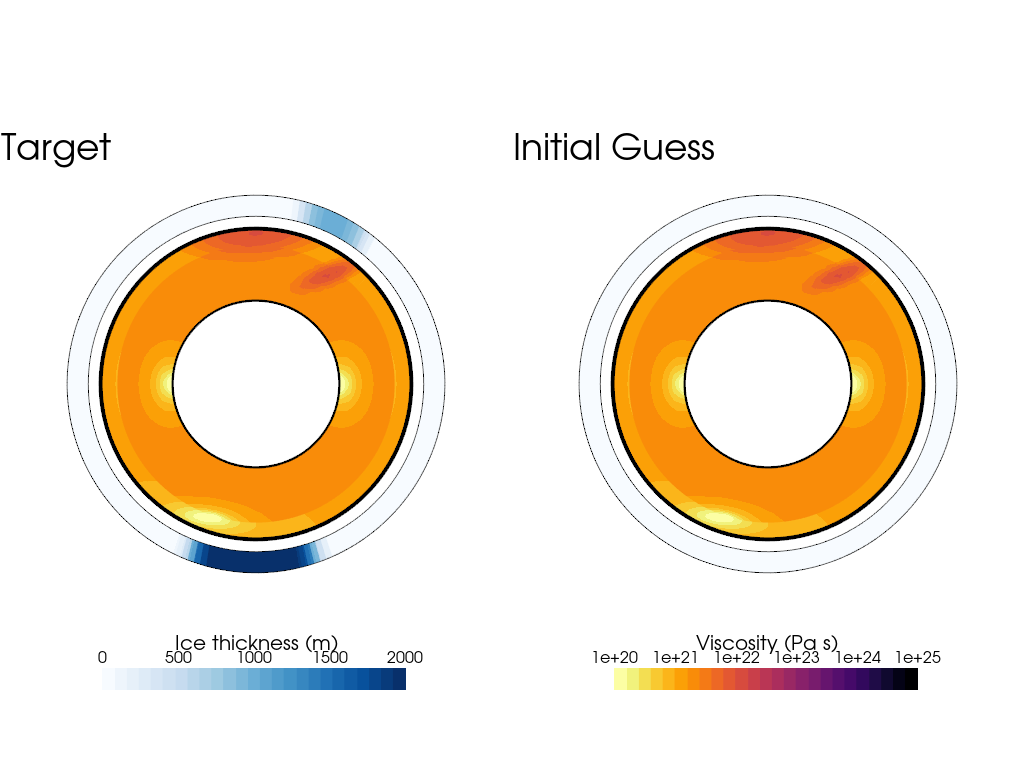

In [14]:
import pyvista as pv
import matplotlib.pyplot as plt

plot_kwargs = {'scalar_bar_vertical': False,
               'scalar_bar_x': 0.2,
               'scalar_bar_y':0.1}

text_pos = (1,600)

updated_ice_file = VTKFile('ice.pvd').write(control_ice_thickness, target_normalised_ice_thickness)
reader = pv.get_reader("ice.pvd")

# Create a plotter object
plotter = pv.Plotter(shape=(1, 2), border=False, notebook=True, off_screen=False)

plotter.subplot(0, 0)
plot_ice_ring(plotter, scalar='target normalised ice thickness', **plot_kwargs)
plot_viscosity(plotter,show_scalar_bar=False)
plotter.add_text("Target", position=text_pos)
plotter.camera_position = 'xy'

plotter.subplot(0, 1)
plot_ice_ring(plotter, scalar='control normalised ice thickness')
plot_viscosity(plotter, **plot_kwargs)
plotter.add_text("Initial Guess", position=text_pos)
plotter.camera_position = 'xy'

plotter.show(jupyter_backend="static", interactive=False)
plotter.close()

Let's choose a timestep 250 years as before.

In [15]:
# Timestepping parameters
Tstart = 0
year_in_seconds = 3600*24*365.25
time = Function(R).assign(Tstart * year_in_seconds)

dt_years = 250
dt = Constant(dt_years * year_in_seconds/characteristic_maxwell_time)
Tend_years = 10e3
Tend = Constant(Tend_years * year_in_seconds/characteristic_maxwell_time)
dt_out_years = 1e3
dt_out = Constant(dt_out_years * year_in_seconds/characteristic_maxwell_time)

max_timesteps = round((Tend - Tstart * year_in_seconds/characteristic_maxwell_time) / dt)

output_frequency = round(dt_out / dt)

We also need to specify boundary conditions, a G-ADOPT approximation, nullspaces and finally the
Stokes solver.

In [16]:
stokes_bcs = {boundary.top: {'free_surface': {'normal_stress': ice_load}},
              boundary.bottom: {'un': 0}
              }

approximation = MaxwellApproximation(
    bulk_modulus=bulk_modulus,
    density=density,
    shear_modulus=shear_modulus,
    viscosity=viscosity,
    B_mu=B_mu,
    bulk_shear_ratio=bulk_shear_ratio)

iterative_parameters = {"mat_type": "matfree",
                        "snes_type": "ksponly",
                        "ksp_type": "gmres",
                        "ksp_rtol": 1e-5,
                        "ksp_converged_reason": None,
                        "pc_type": "python",
                        "pc_python_type": "firedrake.AssembledPC",
                        "assembled_pc_type": "gamg",
                        "assembled_mg_levels_pc_type": "sor",
                        "assembled_pc_gamg_threshold": 0.01,
                        "assembled_pc_gamg_square_graph": 100,
                        "assembled_pc_gamg_coarse_eq_limit": 1000,
                        "assembled_pc_gamg_mis_k_minimum_degree_ordering": True,
                        }

nullspace = rigid_body_modes(V, rotational=True)
near_nullspace = rigid_body_modes(V, rotational=True, translations=[0, 1])

stokes_solver = InternalVariableSolver(
    u,
    approximation,
    dt=dt,
    internal_variables=m,
    bcs=stokes_bcs,
    solver_parameters=iterative_parameters,
    nullspace=nullspace,
    transpose_nullspace=nullspace,
    near_nullspace=near_nullspace
)

We next set up our output in VTK format. This format can be read by programs like pyvista and Paraview.

In [17]:
# Create a velocity function for plotting
velocity = Function(V, name="velocity")
disp_old = Function(V, name="old_disp")
# Create output file
output_file = VTKFile("output.pvd")
output_file.write(u, m, velocity)

plog = ParameterLog("params.log", mesh)
plog.log_str(
    "timestep time dt u_rms u_rms_surf uv_min"
)

checkpoint_filename = "viscoelastic_loading-chk.h5"

gd = GeodynamicalDiagnostics(u, bottom_id=boundary.bottom, top_id=boundary.top)

Now is a good time to setup a helper function for defining the time integrated misfit that we need
later as part of our overall objective function. This is going to be called at each timestep of
the forward run to calculate the difference between the displacement and velocity at the surface
compared our reference forward simulation.

In [18]:
# Overload surface integral measure for G-ADOPT's extruded meshes.
ds = CombinedSurfaceMeasure(mesh, degree=6)


def integrated_time_misfit(timestep, velocity_misfit, displacement_misfit):
    with CheckpointFile(checkpoint_file, 'r') as afile:
        target_displacement = afile.load_function(mesh, name="displacement", idx=timestep)
        target_velocity = afile.load_function(mesh, name="velocity", idx=timestep)
    circumference = 2 * pi * radius_values_nondim[0]
    velocity_error = velocity - target_velocity
    velocity_scale = 1e-5
    velocity_misfit += assemble(dot(velocity_error, velocity_error) / (circumference * velocity_scale**2) * ds(boundary.top))

    displacement_error = u - target_displacement
    displacement_scale = 1e-4
    displacement_misfit += assemble(dot(displacement_error, displacement_error) / (circumference * displacement_scale**2) * ds(boundary.top))
    return velocity_misfit, displacement_misfit

Now let's run the simulation! This is the same as the previous tutorial except we are calculating the surface
misfit between our current simulation and the reference run at each timestep.

In [19]:
velocity_misfit = 0
displacement_misfit = 0

for timestep in range(1, max_timesteps+1):

    time.assign(time+dt)
    stokes_solver.solve()

    velocity.interpolate((u - disp_old)/dt)
    disp_old.assign(u)

    velocity_misfit, displacement_misfit = integrated_time_misfit(timestep, velocity_misfit, displacement_misfit)

    # Log diagnostics:
    plog.log_str(f"{timestep} {time} {float(dt)} {gd.u_rms()} "
                 f"{gd.u_rms_top()} {gd.ux_max(boundary.top)} "
                 f"{gd.uv_min(boundary.top)}"
                 )

    if timestep % output_frequency == 0:
        log("timestep", timestep)

        output_file.write(u, m, velocity)

        with CheckpointFile(checkpoint_filename, "w") as checkpoint:
            checkpoint.save_function(u, name="displacement")
            checkpoint.save_function(m, name="internal variable")

[0]PETSC ERROR: --------------------- Error Message --------------------------------------------------------------
[0]PETSC ERROR:   It appears a new error in the code was triggered after a previous error, possibly because:
[0]PETSC ERROR:   -  The first error was not properly handled via (for example) the use of
[0]PETSC ERROR:      PetscCall(TheFunctionThatErrors()); or
[0]PETSC ERROR:   -  The second error was triggered while handling the first error.
[0]PETSC ERROR:   Above is the traceback for the previous unhandled error, below the traceback for the next error
[0]PETSC ERROR:   ALL ERRORS in the PETSc libraries are fatal, you should add the appropriate error checking to the code
[0]PETSC ERROR: Error in external library
[0]PETSC ERROR: Error in HDF5 call H5Fflush() Status -1
[0]PETSC ERROR: WARNING! There are unused option(s) set! Could be the program crashed before usage or a spelling mistake, etc!
[0]PETSC ERROR:   Option left: name:-f value: /home/wis15/.local/share/jupyter/ru

Error: error code 76

Exception ignored in: 'petsc4py.PETSc.Object.__dealloc__'
Traceback (most recent call last):
  File "<dataclass augmentation code for <class 'pymbolic.primitives.Subscript'>>", line 100, in Subscript_setstate
petsc4py.PETSc.Error: error code 76


    Linear InternalVariable_ solve converged due to CONVERGED_ATOL iterations 0
    Linear InternalVariable_ solve converged due to CONVERGED_ATOL iterations 0
    Linear InternalVariable_ solve converged due to CONVERGED_ATOL iterations 0
    Linear InternalVariable_ solve converged due to CONVERGED_ATOL iterations 0
timestep 4
    Linear InternalVariable_ solve converged due to CONVERGED_ATOL iterations 0
    Linear InternalVariable_ solve converged due to CONVERGED_ATOL iterations 0
    Linear InternalVariable_ solve converged due to CONVERGED_ATOL iterations 0
    Linear InternalVariable_ solve converged due to CONVERGED_ATOL iterations 0
timestep 8
    Linear InternalVariable_ solve converged due to CONVERGED_ATOL iterations 0
    Linear InternalVariable_ solve converged due to CONVERGED_ATOL iterations 0
    Linear InternalVariable_ solve converged due to CONVERGED_ATOL iterations 0


[0]PETSC ERROR: --------------------- Error Message --------------------------------------------------------------
[0]PETSC ERROR:   It appears a new error in the code was triggered after a previous error, possibly because:
[0]PETSC ERROR:   -  The first error was not properly handled via (for example) the use of
[0]PETSC ERROR:      PetscCall(TheFunctionThatErrors()); or
[0]PETSC ERROR:   -  The second error was triggered while handling the first error.
[0]PETSC ERROR:   Above is the traceback for the previous unhandled error, below the traceback for the next error
[0]PETSC ERROR:   ALL ERRORS in the PETSc libraries are fatal, you should add the appropriate error checking to the code
[0]PETSC ERROR: Error in external library
[0]PETSC ERROR: Error in HDF5 call H5Fflush() Status -1
[0]PETSC ERROR: WARNING! There are unused option(s) set! Could be the program crashed before usage or a spelling mistake, etc!
[0]PETSC ERROR:   Option left: name:-f value: /home/wis15/.local/share/jupyter/ru

Error: error code 76

Exception ignored in: 'petsc4py.PETSc.Object.__dealloc__'
Traceback (most recent call last):
  File "/home/wis15/firedrake_installations/fd-main/lib/python3.10/site-packages/ufl/core/compute_expr_hash.py", line 27, in compute_expr_hash
    lifo.append((dep, list(dep.ufl_operands)))
petsc4py.PETSc.Error: error code 76


    Linear InternalVariable_ solve converged due to CONVERGED_ATOL iterations 0
timestep 12
    Linear InternalVariable_ solve converged due to CONVERGED_ATOL iterations 0
    Linear InternalVariable_ solve converged due to CONVERGED_ATOL iterations 0
    Linear InternalVariable_ solve converged due to CONVERGED_ATOL iterations 0
    Linear InternalVariable_ solve converged due to CONVERGED_ATOL iterations 0
timestep 16
    Linear InternalVariable_ solve converged due to CONVERGED_ATOL iterations 0
    Linear InternalVariable_ solve converged due to CONVERGED_ATOL iterations 0
    Linear InternalVariable_ solve converged due to CONVERGED_ATOL iterations 0
    Linear InternalVariable_ solve converged due to CONVERGED_ATOL iterations 0
timestep 20
    Linear InternalVariable_ solve converged due to CONVERGED_ATOL iterations 0
    Linear InternalVariable_ solve converged due to CONVERGED_ATOL iterations 0
    Linear InternalVariable_ solve converged due to CONVERGED_ATOL iterations 0
    

As we can see from the plot below there is no displacement at the final time given there is no ice load!

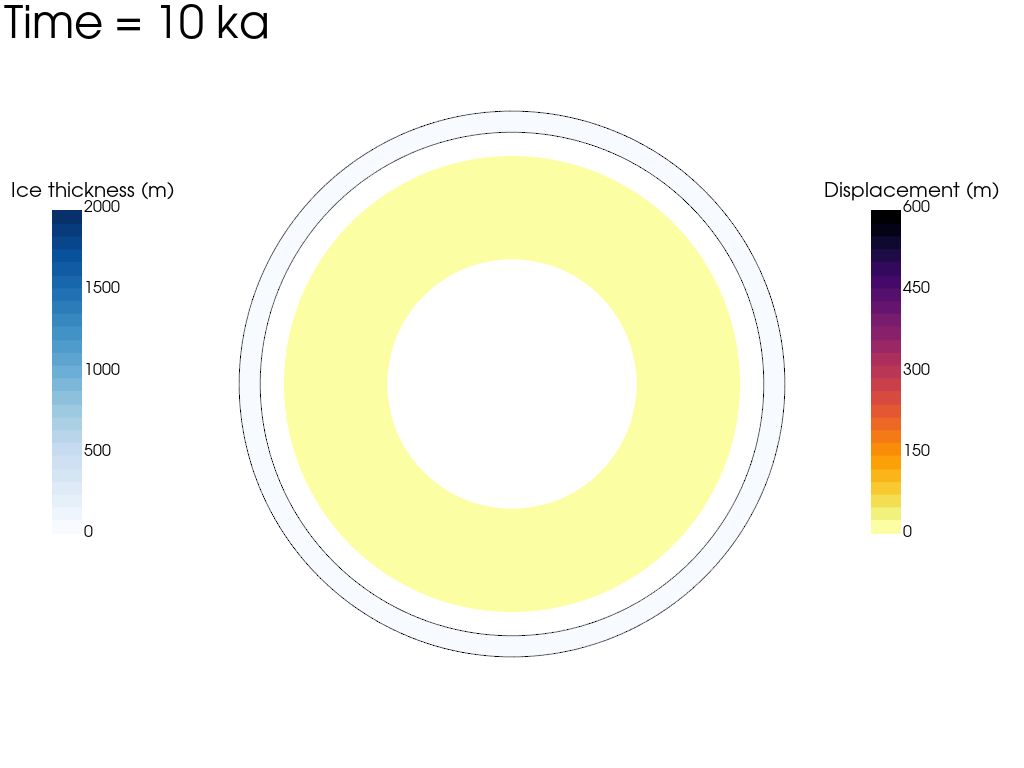

In [20]:
# Create a plotter object
plotter = pv.Plotter(shape=(1, 1), border=False, notebook=True, off_screen=False)

# Plot displacement

disp_scalar_bar_args={
        "title": 'Displacement (m)',
        "position_x": 0.85,
        "position_y": 0.3,
        "vertical": True,
        "title_font_size": 20,
        "label_font_size": 16,
        "fmt": "%.0f",
        "font_family": "arial",
    }
plot_displacement(plotter, disp='displacement', vel='velocity') #, scalar_bar_args=disp_scalar_bar_args)

# Plot ice ring
reader = pv.get_reader("ice.pvd")
ice_scalar_bar_args = {"title": 'Normalised ice thickness',
                       "position_x": 0.1,
                       "position_y": 0.3,
                       "vertical": True,
                       "title_font_size": 22,
                       "label_font_size": 18,
                       "fmt": "%.1f",
                       "font_family": "arial",
                       "n_labels": 5,
                       }
plot_ice_ring(plotter, scalar='control normalised ice thickness')

plotter.camera_position = 'xy'
plotter.add_text("Time = 10 ka")
plotter.show(jupyter_backend="static", interactive=False)
plotter.close()

The inverse problem
------------------------------

Now we can define our overall objective function that we want to minimise.
This includes the time integrated displacement and velocity misfit at the
surface as we discussed above.

In [21]:
J = (displacement_misfit + velocity_misfit) / max_timesteps
log("J = ", J)

J =  0.7463753714535454


Let's also pause annotation as we are now done with the forward terms.

In [22]:
pause_annotation()

Let's setup some call backs to help us keep track of the inversion.

In [23]:
# updated_ice_thickness = Function(normalised_ice_thickness, name="updated ice thickness")
updated_ice_thickness = Function(control_ice_thickness, name="updated ice thickness")
updated_ice_thickness_file = VTKFile("updated_ice_thickness.pvd")
updated_displacement = Function(V, name="updated displacement")
updated_velocity = Function(V, name="updated velocity")
updated_out_file = VTKFile("updated_out.pvd")

with CheckpointFile(checkpoint_file, 'r') as afile:
    final_target_displacement = afile.load_function(mesh, name="displacement", idx=max_timesteps)
    final_target_velocity = afile.load_function(mesh, name="velocity", idx=max_timesteps)

functional_values = []


def eval_cb(J, m):
    if functional_values:
        functional_values.append(min(J, min(functional_values)))
    else:
        functional_values.append(J)

    # Define the component terms of the overall objective functional
    log("displacement misfit", displacement_misfit.block_variable.checkpoint / max_timesteps)
    log("velocity misfit", velocity_misfit.block_variable.checkpoint / max_timesteps)

    # Write out values of control and final forward model results
    updated_ice_thickness.assign(control_ice_thickness.block_variable.checkpoint)
    updated_ice_thickness_file.write(updated_ice_thickness)
    updated_displacement.interpolate(u.block_variable.checkpoint)
    updated_velocity.interpolate(velocity.block_variable.checkpoint)
    updated_out_file.write(updated_displacement, final_target_displacement, updated_velocity, final_target_velocity)

Define the Reduced Functional
-----------------------------
The next important step is to define the reduced functional. This is pyadjoint's way of
associating our objective function with the control variable that we are trying to
optimise. It does this without explicitly depending on all intermediary
state variables, hence the name "reduced".

To define the reduced functional, we provide the class with an objective (which is an overloaded UFL object) and the control.
 We can also pass our call back function which will be called every time
the functional is evaluated.

In [24]:
reduced_functional = ReducedFunctional(J, control, eval_cb_post=eval_cb)

### Verifying the forward tape


A good check to see if the forward taping worked is to rerun the forward model based on
the operations stored on the tape. We can do this by providing the control to the
reducted functional and print out the answer - it is good to see they are the same!

In [25]:
log("J", J)
log("Replay tape RF", reduced_functional(control_ice_thickness_surf))

J 0.7463753714535454
    Linear InternalVariable_ solve converged due to CONVERGED_ATOL iterations 0
    Linear InternalVariable_ solve converged due to CONVERGED_ATOL iterations 0
    Linear InternalVariable_ solve converged due to CONVERGED_ATOL iterations 0
    Linear InternalVariable_ solve converged due to CONVERGED_ATOL iterations 0
    Linear InternalVariable_ solve converged due to CONVERGED_ATOL iterations 0
    Linear InternalVariable_ solve converged due to CONVERGED_ATOL iterations 0
    Linear InternalVariable_ solve converged due to CONVERGED_ATOL iterations 0
    Linear InternalVariable_ solve converged due to CONVERGED_ATOL iterations 0
    Linear InternalVariable_ solve converged due to CONVERGED_ATOL iterations 0
    Linear InternalVariable_ solve converged due to CONVERGED_ATOL iterations 0
    Linear InternalVariable_ solve converged due to CONVERGED_ATOL iterations 0
    Linear InternalVariable_ solve converged due to CONVERGED_ATOL iterations 0
    Linear Internal

### Visualising the derivative

We can now calculate the derivative of our objective function with respect to the
ice thickness.  This is as simple as calling the `derivative()` method on  our
reduced functional.

In [26]:
dJdm = reduced_functional.derivative(apply_riesz=True)

grad_file = VTKFile("adj_ice.pvd").write(dJdm)

    Linear InternalVariable_ solve converged due to CONVERGED_RTOL iterations 22
    Linear InternalVariable_ solve converged due to CONVERGED_RTOL iterations 23
    Linear InternalVariable_ solve converged due to CONVERGED_RTOL iterations 23
    Linear InternalVariable_ solve converged due to CONVERGED_RTOL iterations 23
    Linear InternalVariable_ solve converged due to CONVERGED_RTOL iterations 23
    Linear InternalVariable_ solve converged due to CONVERGED_RTOL iterations 23
    Linear InternalVariable_ solve converged due to CONVERGED_RTOL iterations 23
    Linear InternalVariable_ solve converged due to CONVERGED_RTOL iterations 24
    Linear InternalVariable_ solve converged due to CONVERGED_RTOL iterations 24
    Linear InternalVariable_ solve converged due to CONVERGED_RTOL iterations 24
    Linear InternalVariable_ solve converged due to CONVERGED_RTOL iterations 24
    Linear InternalVariable_ solve converged due to CONVERGED_RTOL iterations 24
    Linear InternalVariable_

We can see there is a clear hemispherical pattern in
the gradients. Red indicates that increasing the ice thickness here would increase
out objective function and blue areas indicates that increasing the ice thickness
here would decrease our objective function. In the 'southern' hemisphere
where we have the biggest ice load the gradient is negative, which makes sense as
we expect increasing the ice thickness here to reduce our surface misfit.

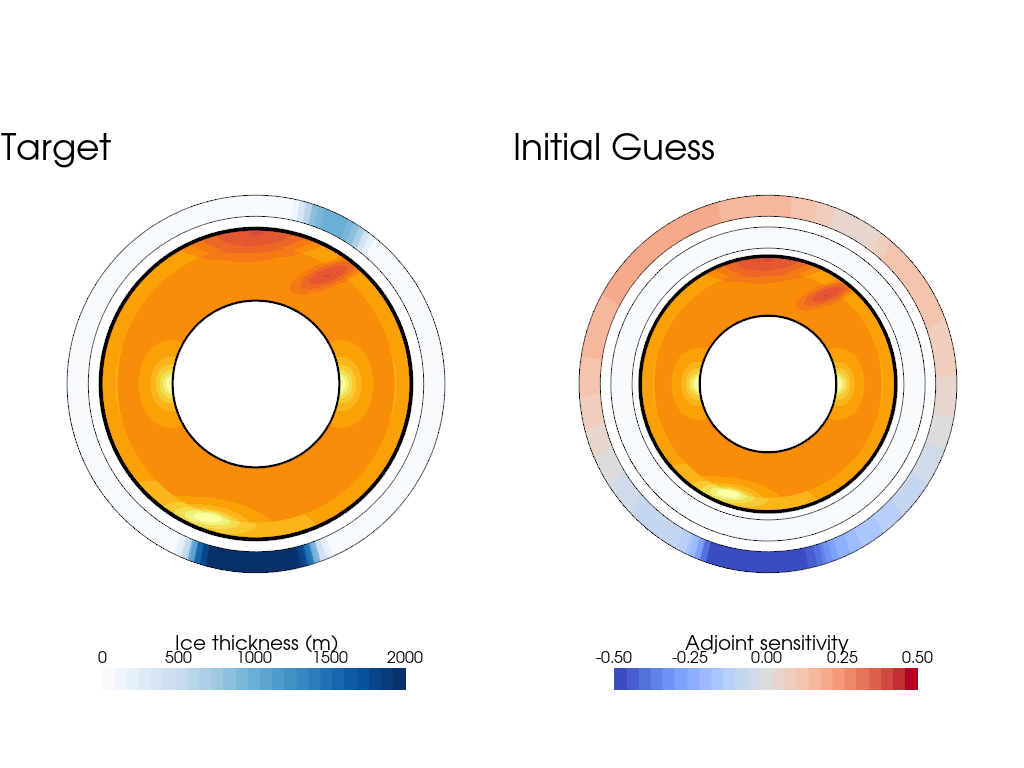

In [27]:
plotter = pv.Plotter(shape=(1, 2), border=False, notebook=True, off_screen=False)
plotter.subplot(0, 0)
plot_ice_ring(plotter, scalar='target normalised ice thickness', **plot_kwargs)
plot_viscosity(plotter, show_scalar_bar=False)
plotter.add_text("Target", position=text_pos)
plotter.camera_position = 'xy'
plotter.subplot(0, 1)
plot_ice_ring(plotter, scalar='control normalised ice thickness')
plot_viscosity(plotter, show_scalar_bar=False)
plot_adj_ring(plotter, fname='adj_ice.pvd', stretch=1.4, **plot_kwargs)
plotter.camera_position = 'xy'
plotter.add_text("Initial Guess", position=text_pos)
plotter.show(jupyter_backend="static", interactive=False)
# Closes and finalizes movie
plotter.close()

### Verification of Gradients via a Taylor Test

A good way to verify this the gradient is correct is to carry out a Taylor test. For the control, $I_h$,
reduced functional, $J(I_h)$, and its derivative,
$\frac{\mathrm{d} J}{\mathrm{d} I_h}$, the Taylor remainder convergence test can be expressed as:

$$ \left| J(I_h + h \,\delta I_h) - J(I_h) - h\,\frac{\mathrm{d} J}{\mathrm{d} I_h} \cdot \delta I_h \right| \longrightarrow 0 \text{ at } O(h^2). $$

The expression on the left-hand side is termed the second-order Taylor remainder. i
This term's convergence rate of $O(h^2)$ is a robust indicator for
verifying the computational implementation of the gradient calculation.
Essentially, if you halve the value of $h$, the magnitude
of the second-order Taylor remainder should decrease by a factor of 4.

We employ these so-called *Taylor tests* to confirm the accuracy of the
determined gradients. The theoretical convergence rate is
$O(2.0)$, and achieving this rate indicates that the gradient information
is accurate down to floating-point precision.

### Performing Taylor Tests

In our implementation, we perform a second-order Taylor remainder test for each
term of the objective functional. The test involves
computing the functional and the associated gradient when randomly perturbing
the ice thickness field, $I_h$, and subsequently
halving the perturbations at each level.

Here is how you can perform a Taylor test in the code:

In [28]:
h = Function(control_ice_thickness_surf)
h.dat.data[:] = np.random.random(h.dat.data_ro.shape)
minconv = taylor_test(reduced_functional, control_ice_thickness_surf, h)

with open("taylor_test_minconv.txt", "w") as f:
    f.write(str(minconv))

    Linear InternalVariable_ solve converged due to CONVERGED_ATOL iterations 0
    Linear InternalVariable_ solve converged due to CONVERGED_ATOL iterations 0
    Linear InternalVariable_ solve converged due to CONVERGED_ATOL iterations 0
    Linear InternalVariable_ solve converged due to CONVERGED_ATOL iterations 0
    Linear InternalVariable_ solve converged due to CONVERGED_ATOL iterations 0
    Linear InternalVariable_ solve converged due to CONVERGED_ATOL iterations 0
    Linear InternalVariable_ solve converged due to CONVERGED_ATOL iterations 0
    Linear InternalVariable_ solve converged due to CONVERGED_ATOL iterations 0
    Linear InternalVariable_ solve converged due to CONVERGED_ATOL iterations 0
    Linear InternalVariable_ solve converged due to CONVERGED_ATOL iterations 0
    Linear InternalVariable_ solve converged due to CONVERGED_ATOL iterations 0
    Linear InternalVariable_ solve converged due to CONVERGED_ATOL iterations 0
    Linear InternalVariable_ solve conve

### Setting up the inversion

Now that we have verified our gradient is correct, let's start setting up an inversion.
First of all we will define some bounds that we enforce the control to lie within.
For this problem the lower bound of zero ice thickness is particularly important,
as we do not want negative ice thicknesses!

In [29]:
ice_thickness_lb = Function(control_ice_thickness_surf.function_space(), name="Lower bound ice thickness")
ice_thickness_ub = Function(control_ice_thickness_surf.function_space(), name="Upper bound ice thickness")
ice_thickness_lb.assign(0.0)
ice_thickness_ub.assign(5)

bounds = [ice_thickness_lb, ice_thickness_ub]

Next we setup a pyadjoint minimization problem. We tweak GADOPT's default minimisation
parameters (found in `gadopt/inverse.py`) for our problem. We limit the number of
iterations to 5 just so that the demo is quick to run. (N.b. 20 iterations gives a
very accurate answer.)

In [30]:
minimisation_problem = MinimizationProblem(reduced_functional, bounds=bounds)

minimisation_parameters["Status Test"]["Iteration Limit"] = 5

optimiser = LinMoreOptimiser(
    minimisation_problem,
    minimisation_parameters,
    checkpoint_dir="optimisation_checkpoint",
)
# Restart file for optimisation...
updated_ice_thickness_file = VTKFile("updated_ice_thickness.pvd")
updated_out_file = VTKFile("updated_out.pvd")
functional_values = []

### Running the inversion

Now let's run the inversion!

In [31]:
optimiser.run()

    Linear InternalVariable_ solve converged due to CONVERGED_RTOL iterations 24
    Linear InternalVariable_ solve converged due to CONVERGED_RTOL iterations 27
    Linear InternalVariable_ solve converged due to CONVERGED_RTOL iterations 27
    Linear InternalVariable_ solve converged due to CONVERGED_RTOL iterations 28
    Linear InternalVariable_ solve converged due to CONVERGED_RTOL iterations 28
    Linear InternalVariable_ solve converged due to CONVERGED_RTOL iterations 28
    Linear InternalVariable_ solve converged due to CONVERGED_RTOL iterations 27
    Linear InternalVariable_ solve converged due to CONVERGED_RTOL iterations 27
    Linear InternalVariable_ solve converged due to CONVERGED_RTOL iterations 26
    Linear InternalVariable_ solve converged due to CONVERGED_RTOL iterations 25
    Linear InternalVariable_ solve converged due to CONVERGED_RTOL iterations 25
    Linear InternalVariable_ solve converged due to CONVERGED_RTOL iterations 26
    Linear InternalVariable_

If we're performing mulitple successive optimisations, we want
to ensure the annotations are switched back on for the next code
to use them

In [32]:
continue_annotation()

True

Let's plot the results of the inversion at the final iteration.

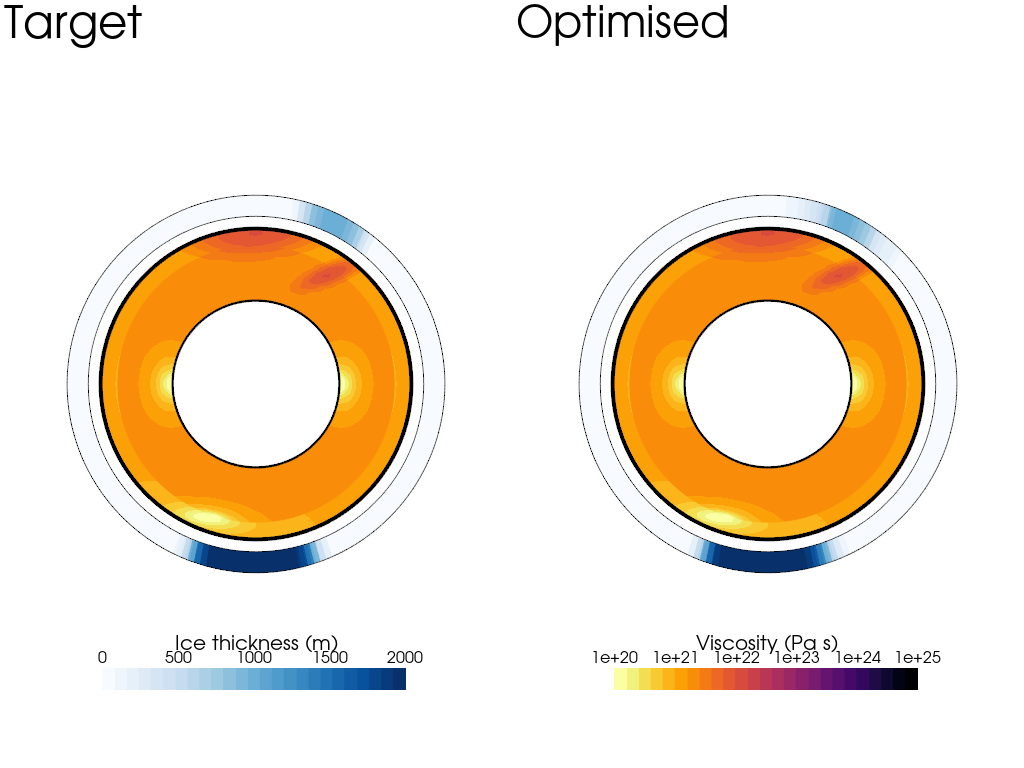

In [33]:
# Read the PVD file

# Create a plotter object
plotter = pv.Plotter(shape=(1, 2), border=False, notebook=True, off_screen=False)
reader = pv.get_reader("updated_out.pvd")
reader.set_active_time_point(5)
plotter.subplot(0, 0)
plot_viscosity(plotter,show_scalar_bar=False)
plotter.add_text("Target")

plotter.subplot(0, 1)
plot_viscosity(plotter, **plot_kwargs)

ice_scalar_bar_args = {"title": 'Normalised ice thickness',
                       "position_x": 0.2,
                       "position_y": 0.1,
                       "vertical": False,
                       "title_font_size": 22,
                       "label_font_size": 18,
                       "fmt": "%.1f",
                       "font_family": "arial",
                       "n_labels": 5,
                       }

reader = pv.get_reader("updated_ice_thickness.pvd")
reader.set_active_time_point(5)
plotter.subplot(0, 0)
plot_ice_ring(plotter, fname='ice.pvd', scalar='target normalised ice thickness', **plot_kwargs)
plotter.camera_position = 'xy'
plotter.subplot(0, 1)
plot_ice_ring(plotter, fname='updated_ice_thickness.pvd', scalar='updated ice thickness', timestep=5, thickness_scale=1000, **plot_kwargs)

plotter.camera_position = 'xy'
plotter.add_text("Optimised")
plotter.show(jupyter_backend="static", interactive=False)
plotter.close()

We can see that we have been able to recover two ice sheets in the correct locations!

And we'll write the functional values to a file so that we can test them.

In [34]:
with open("functional.txt", "w") as f:
    f.write("\n".join(str(x) for x in functional_values))

We can confirm that the surface misfit has reduced by plotting
the objective function at each iteration.

Text(0.5, 1.0, 'Convergence')

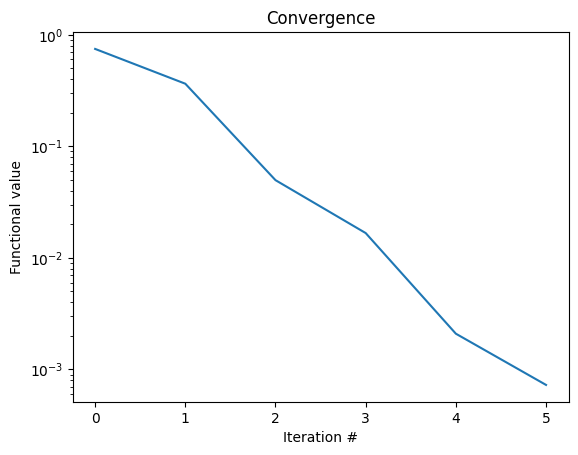

In [35]:
plt.semilogy(functional_values)
plt.xlabel("Iteration #")
plt.ylabel("Functional value")
plt.title("Convergence")